**IMDB Movie Reviews – Cinematic Intelligence
Project -Kuldeep Panwar**
--


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk spacy textblob wordcloud sentence-transformers --quiet
!python -m spacy download en_core_web_md --quiet
!python -m textblob.download_corpora lite

import warnings
warnings.filterwarnings('ignore')
print("✅ All packages installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 74.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
Finished.
✅ All packages installed success

# ============================================================
#  IMPORT ALL LIBRARIES
# ============================================================

In [17]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# NLP Libraries
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

import spacy
from textblob import TextBlob

# ML Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sentence Transformers (BERT)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


# ============================================================
# SECTION 1: LOAD AND INSPECT THE DATASET
# ============================================================

In [4]:
# 1.1 Load the dataset
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [5]:
import io
df = pd.read_csv(io.BytesIO(uploaded['IMDB Dataset.csv']))

In [7]:
# 1.2 Basic shape and info
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names: {list(df.columns)}")
print(f"\n📋 Data Types:\n{df.dtypes}")


📊 Dataset Shape: 50000 rows × 2 columns

📋 Column Names: ['review', 'sentiment']

📋 Data Types:
review       object
sentiment    object
dtype: object



--- First 5 Reviews ---


,review,sentiment,review_length,word_count_raw,sentiment_label
0,One of the other reviewers has mentioned that ...,positive,1761,307,1
1,A wonderful little production. <br /><br />The...,positive,998,162,1
2,I thought this was a wonderful way to spend ti...,positive,926,166,1
3,Basically there's a family where a little boy ...,negative,748,138,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230,1



 Missing Values:
review             0
sentiment          0
review_length      0
word_count_raw     0
sentiment_label    0
dtype: int64

 Duplicate Rows: 418

 Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


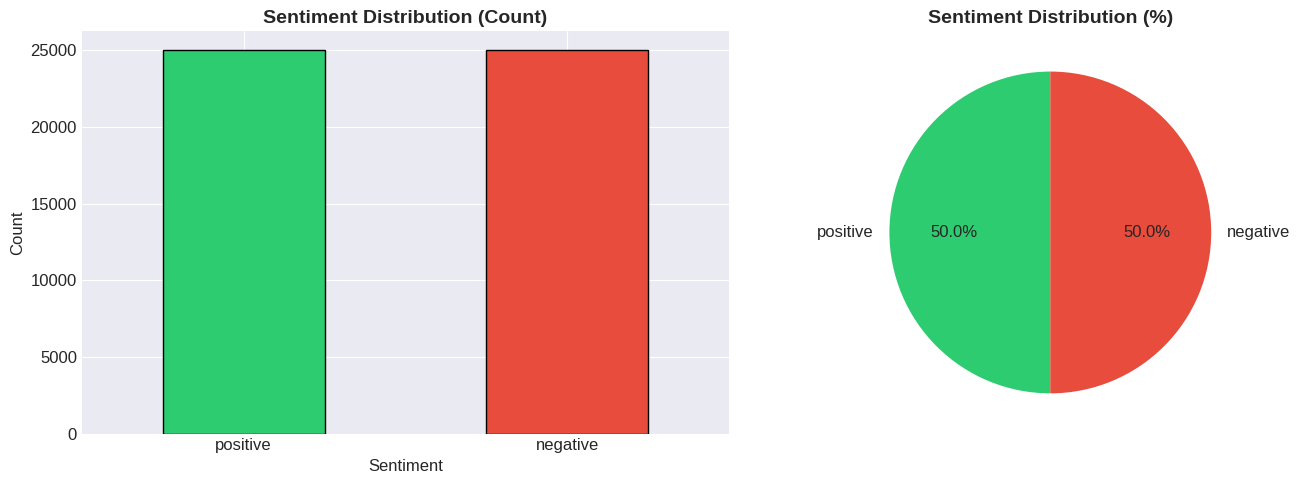


 Review Length Statistics (characters):
count    50000.00
mean      1309.43
std        989.73
min         32.00
25%        699.00
50%        970.00
75%       1590.25
max      13704.00
Name: review_length, dtype: float64

 Word Count Statistics:
count    50000.00
mean       231.16
std        171.34
min          4.00
25%        126.00
50%        173.00
75%        280.00
max       2470.00
Name: word_count_raw, dtype: float64


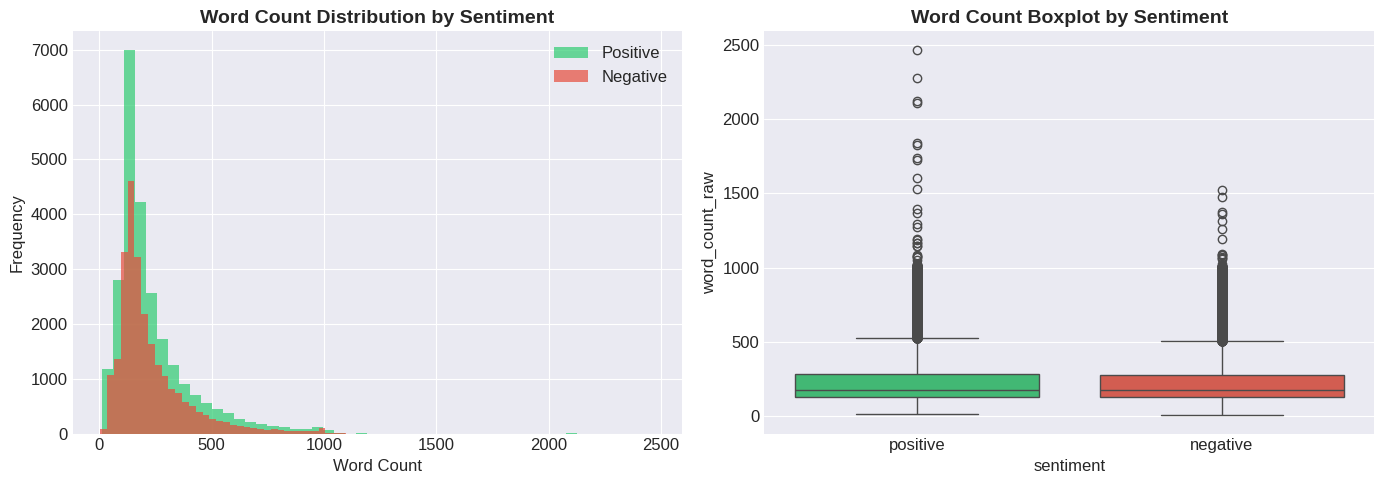


 Target label encoded: positive=1, negative=0
 Working sample: 50000 reviews selected for processing


In [10]:
# 1.3 First 5 rows
print("\n--- First 5 Reviews ---")
display(df.head())
# 1.4 Check for missing values and duplicates
print(f"\n Missing Values:\n{df.isnull().sum()}")
print(f"\n Duplicate Rows: {df.duplicated().sum()}")
# 1.5 Sentiment distribution
print(f"\n Sentiment Distribution:\n{df['sentiment'].value_counts()}")
# 1.6 Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Sentiment Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
# Pie chart
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                      colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Sentiment Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()
# 1.7 Review length statistics
df['review_length'] = df['review'].apply(len)
df['word_count_raw'] = df['review'].apply(lambda x: len(x.split()))
print(f"\n Review Length Statistics (characters):")
print(df['review_length'].describe().round(2))
print(f"\n Word Count Statistics:")
print(df['word_count_raw'].describe().round(2))
# 1.8 Distribution of review lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[df['sentiment']=='positive']['word_count_raw'], bins=50, alpha=0.7, label='Positive', color='#2ecc71')
axes[0].hist(df[df['sentiment']=='negative']['word_count_raw'], bins=50, alpha=0.7, label='Negative', color='#e74c3c')
axes[0].set_title('Word Count Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
sns.boxplot(x='sentiment', y='word_count_raw', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Word Count Boxplot by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# 1.9 Encode target variable
df['sentiment_label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(f"\n Target label encoded: positive=1, negative=0")
# 1.10 Sample for faster processing (use full dataset if time permits)
SAMPLE_SIZE = len(df)
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).copy().reset_index(drop=True)
print(f" Working sample: {len(df_sample)} reviews selected for processing")

# =============================================
# SECTION 2: CLEAN AND NORMALIZE TEXT
# =============================================

In [12]:
def clean_and_normalize(text):
    """
    Comprehensive text cleaning pipeline:
    1. Remove HTML tags (<br />, <p>, etc.)
    2. Convert to lowercase
    3. Remove URLs
    4. Remove email addresses
    5. Remove special characters and numbers
    6. Remove extra whitespace
    7. Strip leading/trailing spaces
    """
    # Step 1: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Step 2: Convert to lowercase
    text = text.lower()

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 4: Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Step 5: Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Step 7: Strip
    text = text.strip()

    return text
# Apply cleaning
print("\n Cleaning and normalizing text...")
df_sample['cleaned_review'] = df_sample['review'].apply(clean_and_normalize)
print(" Text cleaning complete!")
# Show Before vs After comparison
print("\n--- Before vs After Cleaning (First 3 Reviews) ---")
for i in range(3):
    print(f"\n{'='*50}")
    print(f" ORIGINAL (first 200 chars):\n{df_sample['review'].iloc[i][:200]}...")
    print(f"\n CLEANED (first 200 chars):\n{df_sample['cleaned_review'].iloc[i][:200]}...")
# Verify cleaning worked — check that no HTML remains
html_remaining = df_sample['cleaned_review'].apply(lambda x: bool(re.search(r'<[^>]+>', x))).sum()
print(f"\n Reviews still containing HTML tags: {html_remaining}")
# Word count after cleaning
df_sample['cleaned_word_count'] = df_sample['cleaned_review'].apply(lambda x: len(x.split()))
print(f"\n Cleaned Review Word Count Stats:")
print(df_sample['cleaned_word_count'].describe().round(2))


 Cleaning and normalizing text...
 Text cleaning complete!

--- Before vs After Cleaning (First 3 Reviews) ---

 ORIGINAL (first 200 chars):
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...

 CLEANED (first 200 chars):
i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslams ever i...

 ORIGINAL (first 200 chars):
Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you ca...

 CLEANED (first 200 chars):
not many television shows appeal to quite as many different kinds of fans like farscape doesi know youngsters and years oldfans both male and female in as man

# =========================================================
# SECTION 3: TOKENIZE, REMOVE STOPWORDS, AND LEMMATIZE
# =========================================================

In [14]:
#  Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
print(f"\nTotal English Stopwords: {len(stop_words)}")
print(f" Sample Stopwords: {list(stop_words)[:20]}")



Total English Stopwords: 198
 Sample Stopwords: ['some', "aren't", 'itself', 'had', 'an', 'off', 'should', 'ma', 'won', 'its', 'hasn', 'that', "we've", 'isn', 'in', 'have', 'herself', 'once', "he's", 'here']


In [15]:
#  Tokenization function
def tokenize_text(text):
    """Tokenize text into individual words"""
    tokens = word_tokenize(text)
    return tokens

In [16]:
#  Apply tokenization
print("\n Step 1: Tokenizing text...")
df_sample['tokens'] = df_sample['cleaned_review'].apply(tokenize_text)
print(" Tokenization complete!")
# Show token example
print(f"\n--- Tokenization Example ---")
print(f"Text: {df_sample['cleaned_review'].iloc[0][:100]}...")
print(f"Tokens (first 20): {df_sample['tokens'].iloc[0][:20]}")
print(f"Total tokens: {len(df_sample['tokens'].iloc[0])}")


 Step 1: Tokenizing text...
 Tokenization complete!

--- Tokenization Example ---
Text: i really liked this summerslam due to the look of the arena the curtains and just the look overall w...
Tokens (first 20): ['i', 'really', 'liked', 'this', 'summerslam', 'due', 'to', 'the', 'look', 'of', 'the', 'arena', 'the', 'curtains', 'and', 'just', 'the', 'look', 'overall', 'was']
Total tokens: 199


In [19]:
#  Remove stopwords
def remove_stopwords(tokens):
    """Remove English stopwords from token list"""
    return [token for token in tokens if token not in stop_words and len(token) > 2]
print("\n Step 2: Removing stopwords...")
df_sample['tokens_no_stop'] = df_sample['tokens'].apply(remove_stopwords)
print(" Stopword removal complete!")
# Show effect of stopword removal
sample_idx = 0
print(f"\n--- Stopword Removal Example ---")
print(f"Before (count): {len(df_sample['tokens'].iloc[sample_idx])}")
print(f"After  (count): {len(df_sample['tokens_no_stop'].iloc[sample_idx])}")
removed = len(df_sample['tokens'].iloc[sample_idx]) - len(df_sample['tokens_no_stop'].iloc[sample_idx])
print(f"Stopwords removed: {removed}")


 Step 2: Removing stopwords...
 Stopword removal complete!

--- Stopword Removal Example ---
Before (count): 199
After  (count): 110
Stopwords removed: 89


In [20]:
#  Lemmatization
def lemmatize_tokens(tokens):
    """Lemmatize each token to its base form"""
    return [lemmatizer.lemmatize(token, pos='v') for token in tokens]
print("\n Step 3: Lemmatizing tokens...")
df_sample['tokens_lemmatized'] = df_sample['tokens_no_stop'].apply(lemmatize_tokens)
print(" Lemmatization complete!")
# Show lemmatization effect
print(f"\n--- Lemmatization Example ---")
before_lemma = df_sample['tokens_no_stop'].iloc[0][:15]
after_lemma = df_sample['tokens_lemmatized'].iloc[0][:15]
lemma_comparison = pd.DataFrame({'Before': before_lemma, 'After': after_lemma})
display(lemma_comparison)


 Step 3: Lemmatizing tokens...
 Lemmatization complete!

--- Lemmatization Example ---


,Before,After
0,really,really
1,liked,like
2,summerslam,summerslam
3,due,due
4,look,look
5,arena,arena
6,curtains,curtain
7,look,look
8,overall,overall
9,interesting,interest



 Token Count Statistics (After Full Pipeline):
count    50000.00
mean       117.46
std         88.59
min          3.00
25%         63.00
50%         87.00
75%        143.00
max       1395.00
Name: final_token_count, dtype: float64


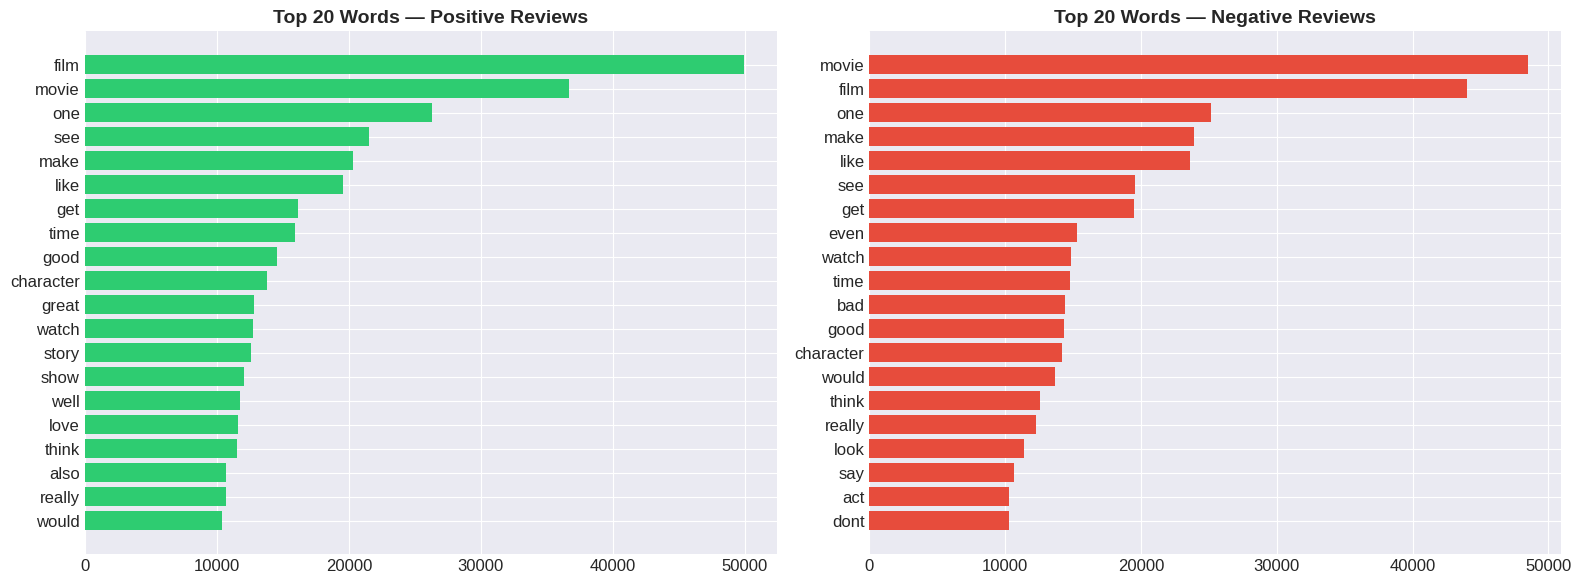

In [22]:
#  Create final processed text column
df_sample['processed_review'] = df_sample['tokens_lemmatized'].apply(lambda x: ' '.join(x))
#  Token count statistics
df_sample['final_token_count'] = df_sample['tokens_lemmatized'].apply(len)
print(f"\n Token Count Statistics (After Full Pipeline):")
print(df_sample['final_token_count'].describe().round(2))
#  Visualize most common words (Positive vs Negative)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Positive reviews — top 20 words
pos_tokens = df_sample[df_sample['sentiment_label'] == 1]['tokens_lemmatized'].explode()
pos_freq = Counter(pos_tokens).most_common(20)
axes[0].barh([w[0] for w in pos_freq][::-1], [w[1] for w in pos_freq][::-1], color='#2ecc71')
axes[0].set_title('Top 20 Words — Positive Reviews', fontsize=14, fontweight='bold')
# Negative reviews — top 20 words
neg_tokens = df_sample[df_sample['sentiment_label'] == 0]['tokens_lemmatized'].explode()
neg_freq = Counter(neg_tokens).most_common(20)
axes[1].barh([w[0] for w in neg_freq][::-1], [w[1] for w in neg_freq][::-1], color='#e74c3c')
axes[1].set_title('Top 20 Words — Negative Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


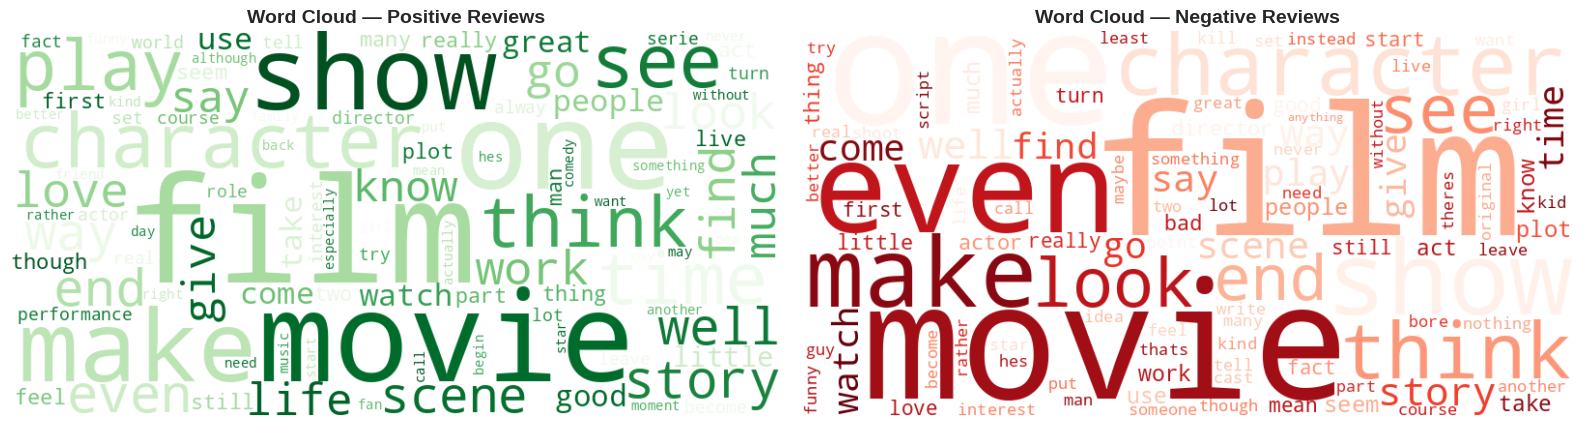


✅ Section 3 Complete: Tokenization → Stopword Removal → Lemmatization pipeline applied.


In [23]:
#  Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
pos_text = ' '.join(df_sample[df_sample['sentiment_label'] == 1]['processed_review'])
neg_text = ' '.join(df_sample[df_sample['sentiment_label'] == 0]['processed_review'])
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(neg_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Word Cloud — Positive Reviews', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Word Cloud — Negative Reviews', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print("\n✅ Section 3 Complete: Tokenization → Stopword Removal → Lemmatization pipeline applied.")

# ============================================================
# SECTION 4: TF-IDF FEATURES & BASELINE CLASSIFIER
# ============================================================

In [24]:
#  Generate TF-IDF Feature Matrix
print("\n Step 1: Generating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,       # Top 10,000 features
    ngram_range=(1, 2),       # Unigrams + Bigrams
    min_df=3,                 # Minimum document frequency
    max_df=0.95,              # Maximum document frequency
    sublinear_tf=True         # Apply sublinear TF scaling
)
X_tfidf = tfidf_vectorizer.fit_transform(df_sample['processed_review'])
y = df_sample['sentiment_label']
print(f" TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"   → {X_tfidf.shape[0]} documents × {X_tfidf.shape[1]} features")


 Step 1: Generating TF-IDF features...
 TF-IDF Matrix Shape: (50000, 10000)
   → 50000 documents × 10000 features


In [25]:
# Show top TF-IDF features
feature_names = tfidf_vectorizer.get_feature_names_out()
avg_tfidf = X_tfidf.mean(axis=0).A1
top_features_idx = avg_tfidf.argsort()[-20:][::-1]
print(f"\n Top 20 TF-IDF Features (by avg score):")
for rank, idx in enumerate(top_features_idx, 1):
    print(f"   {rank:2d}. {feature_names[idx]:20s} → {avg_tfidf[idx]:.4f}")


 Top 20 TF-IDF Features (by avg score):
    1. movie                → 0.0349
    2. film                 → 0.0333
    3. one                  → 0.0248
    4. see                  → 0.0233
    5. make                 → 0.0231
    6. like                 → 0.0230
    7. get                  → 0.0204
    8. watch                → 0.0197
    9. good                 → 0.0195
   10. time                 → 0.0193
   11. character            → 0.0179
   12. think                → 0.0174
   13. even                 → 0.0169
   14. really               → 0.0168
   15. would                → 0.0168
   16. story                → 0.0166
   17. show                 → 0.0154
   18. great                → 0.0153
   19. bad                  → 0.0150
   20. well                 → 0.0149


In [27]:
#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Train-Test Split:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set:     {X_test.shape[0]} samples")


 Train-Test Split:
   Training set: 40000 samples
   Test set:     10000 samples


In [28]:
# Train Multiple Baseline Classifiers
print("\n Step 2: Training multiple classifiers for comparison...")
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(alpha=1.0),
    'Linear SVM (SVC)': LinearSVC(max_iter=2000, random_state=42)
}
results = {}
best_model = None
best_accuracy = 0
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # Cross-validation score
    cv_scores = cross_val_score(model, X_tfidf, y, cv=5, scoring='accuracy')

    print(f"\n{'─'*50}")
    print(f" Model: {name}")
    print(f"   Test Accuracy:     {acc:.4f} ({acc*100:.2f}%)")
    print(f"   CV Mean Accuracy:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = (name, model, y_pred)


 Step 2: Training multiple classifiers for comparison...

──────────────────────────────────────────────────
 Model: Logistic Regression
   Test Accuracy:     0.9004 (90.04%)
   CV Mean Accuracy:  0.8959 ± 0.0012

──────────────────────────────────────────────────
 Model: Multinomial Naive Bayes
   Test Accuracy:     0.8684 (86.84%)
   CV Mean Accuracy:  0.8685 ± 0.0023

──────────────────────────────────────────────────
 Model: Linear SVM (SVC)
   Test Accuracy:     0.8916 (89.16%)
   CV Mean Accuracy:  0.8889 ± 0.0014


In [29]:
# Detailed Classification Report for Best Model
print(f"\n{'='*50}")
print(f" BEST MODEL: {best_model[0]} (Accuracy: {best_accuracy:.4f})")
print(f"{'='*50}")
print(f"\n Detailed Classification Report:")
print(classification_report(y_test, best_model[2], target_names=['Negative', 'Positive']))


 BEST MODEL: Logistic Regression (Accuracy: 0.9004)

 Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



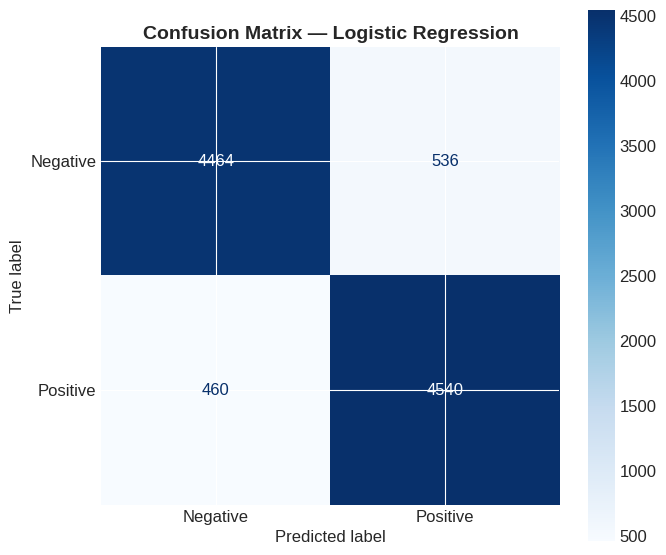

In [30]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_model[2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — {best_model[0]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

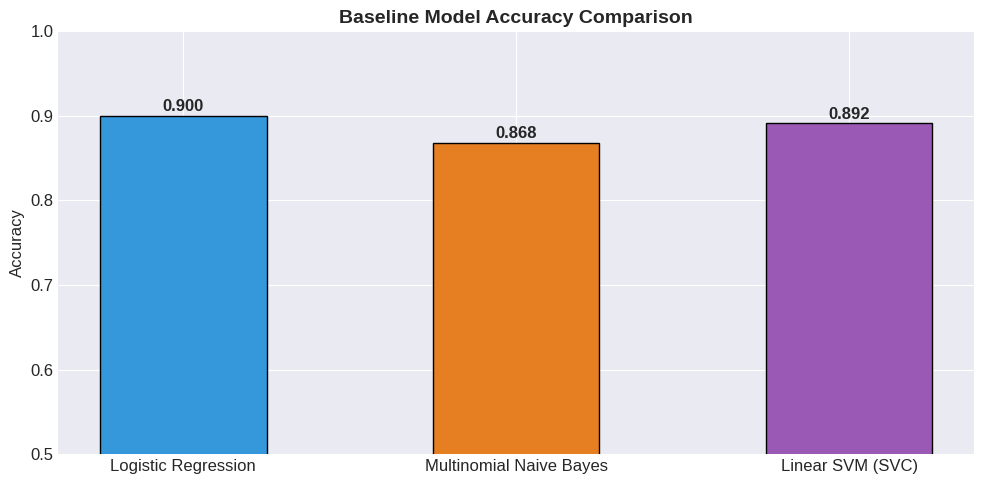

In [31]:
#  Model Accuracy Comparison Chart
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
accuracies = list(results.values())
colors = ['#3498db', '#e67e22', '#9b59b6']
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_title('Baseline Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
# Add predictions to dataframe using best model
best_clf = best_model[1]
df_sample['tfidf_predicted_sentiment'] = best_clf.predict(X_tfidf)
df_sample['tfidf_predicted_label'] = df_sample['tfidf_predicted_sentiment'].map({1: 'positive', 0: 'negative'})
print(f"\n Section 4 Complete: TF-IDF baseline classifier trained. Best = {best_model[0]} ({best_accuracy*100:.2f}%)")


 Section 4 Complete: TF-IDF baseline classifier trained. Best = Logistic Regression (90.04%)


# ============================================================
# SECTION 5: EMBEDDING-BASED EMOTION SCORES
# ============================================================

In [34]:
#  Load SpaCy model with word vectors
print("\n Loading SpaCy word vectors (en_core_web_md)...")
nlp = spacy.load("en_core_web_md")
print(" SpaCy model loaded!")
#  Define emotion seed lexicons with expanded keywords
emotion_lexicon = {
    'joy':      ['happy', 'joy', 'wonderful', 'amazing', 'brilliant', 'love', 'fantastic',
                 'beautiful', 'excellent', 'delight', 'pleasure', 'cheerful', 'great'],
    'anger':    ['angry', 'hate', 'furious', 'terrible', 'awful', 'mad', 'rage',
                 'annoyed', 'irritated', 'hostile', 'outraged', 'infuriating'],
    'sadness':  ['sad', 'depressed', 'tragic', 'crying', 'heartbreak', 'sorrow',
                 'miserable', 'grief', 'melancholy', 'painful', 'devastating'],
    'surprise': ['surprise', 'shocked', 'unexpected', 'twist', 'unbelievable',
                 'astonishing', 'stunning', 'remarkable', 'startling', 'incredible'],
    'disgust':  ['disgust', 'gross', 'sick', 'repulsive', 'revolting', 'nasty',
                 'horrible', 'vile', 'dreadful', 'appalling', 'atrocious']
}


 Loading SpaCy word vectors (en_core_web_md)...
 SpaCy model loaded!


In [35]:
# Pre-compute average embedding vector for each emotion
print("\n Computing emotion reference vectors...")
emotion_vectors = {}
for emotion, keywords in emotion_lexicon.items():
    vectors = []
    for word in keywords:
        doc = nlp(word)
        if doc.has_vector and np.linalg.norm(doc.vector) > 0:
            vectors.append(doc.vector)
    emotion_vectors[emotion] = np.mean(vectors, axis=0)
    print(f"   ✓ {emotion:10s}: {len(vectors)} seed words averaged")


 Computing emotion reference vectors...
   ✓ joy       : 13 seed words averaged
   ✓ anger     : 12 seed words averaged
   ✓ sadness   : 11 seed words averaged
   ✓ surprise  : 10 seed words averaged
   ✓ disgust   : 11 seed words averaged


In [41]:
# Function to compute emotion profile
def compute_emotion_scores(text):
    """
    Compute cosine similarity between the review's word vector
    and each emotion's reference vector. Returns a dictionary
    of emotion scores (0 to 1).
    """
    doc = nlp(text)

    # If no vector, return zeros
    if not doc.has_vector or np.linalg.norm(doc.vector) == 0:
        return {emotion: 0.0 for emotion in emotion_vectors}

    doc_vec = doc.vector.reshape(1, -1)
    scores = {}
    for emotion, ref_vec in emotion_vectors.items():
        sim = cosine_similarity(doc_vec, ref_vec.reshape(1, -1))[0][0]
        scores[emotion] = round(max(float(sim), 0.0), 4)
    return scores

# Apply emotion scoring
print("\n Computing emotion scores for all reviews...")
df_sample['emotion_scores'] = df_sample['processed_review'].apply(compute_emotion_scores)
print(" Emotion scoring complete!")


 Computing emotion scores for all reviews...
 Emotion scoring complete!


In [44]:
#  Expand emotion scores into separate columns
emotion_df = pd.DataFrame(df_sample['emotion_scores'].tolist())
for col in emotion_df.columns:
    df_sample[f'emotion_{col}'] = emotion_df[col]
#  Display emotion scores for sample reviews
print("\n--- Emotion Scores for First 5 Reviews ---")
emotion_cols = [f'emotion_{e}' for e in emotion_lexicon.keys()]
display(df_sample[['sentiment'] + emotion_cols].head())
#  Average emotion scores by sentiment class
print("\n Average Emotion Scores by Sentiment:")
emotion_by_sentiment = df_sample.groupby('sentiment')[emotion_cols].mean().round(4)
display(emotion_by_sentiment)


--- Emotion Scores for First 5 Reviews ---


,sentiment,emotion_joy,emotion_anger,emotion_sadness,emotion_surprise,emotion_disgust
0,positive,0.6943,0.7452,0.6749,0.6217,0.7335
1,positive,0.8251,0.7416,0.7009,0.6451,0.7195
2,negative,0.8020,0.7910,0.7377,0.6734,0.7782
3,positive,0.8175,0.7782,0.6956,0.6537,0.7427
4,negative,0.8229,0.8259,0.7474,0.6595,0.7910



 Average Emotion Scores by Sentiment:


,emotion_joy,emotion_anger,emotion_sadness,emotion_surprise,emotion_disgust
sentiment,,,,,
negative,0.7992,0.7991,0.7398,0.6541,0.7809
positive,0.8099,0.7822,0.7318,0.6589,0.7603


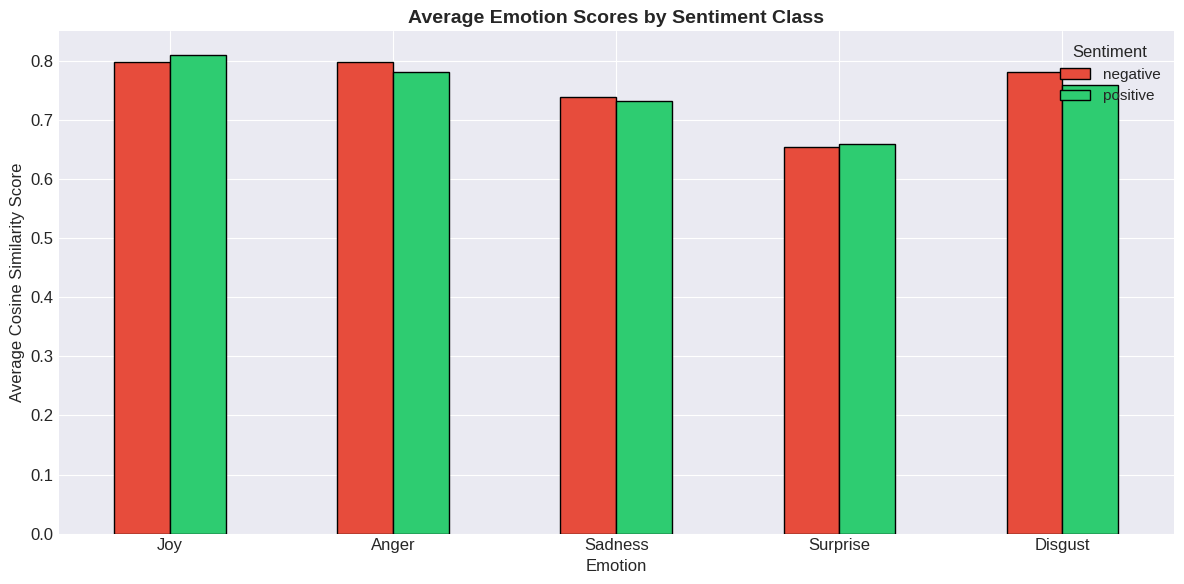

In [45]:
#  Visualize emotion profiles
fig, ax = plt.subplots(figsize=(12, 6))
emotion_by_sentiment.T.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Average Emotion Scores by Sentiment Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Average Cosine Similarity Score')
ax.set_xticklabels([e.replace('emotion_', '').title() for e in emotion_cols], rotation=0)
ax.legend(title='Sentiment', fontsize=11)
plt.tight_layout()
plt.show()


 Dominant Emotion Distribution:
dominant_emotion
joy        31023
anger      17752
disgust     1173
sadness       52
Name: count, dtype: int64


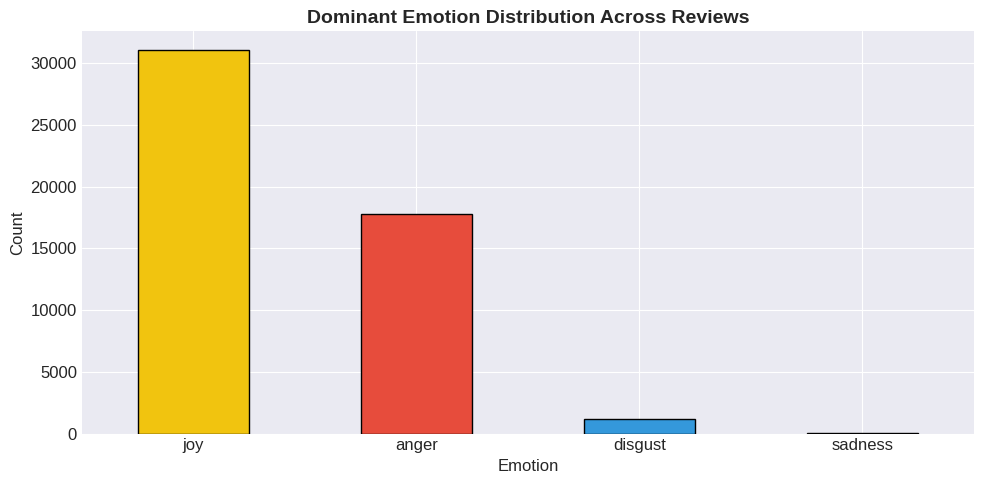


 Section 5 Complete: Embedding-based emotion scores computed for all reviews.


In [46]:
#  Dominant emotion per review
df_sample['dominant_emotion'] = df_sample['emotion_scores'].apply(
    lambda x: max(x, key=x.get)
)
print("\n Dominant Emotion Distribution:")
print(df_sample['dominant_emotion'].value_counts())
fig, ax = plt.subplots(figsize=(10, 5))
df_sample['dominant_emotion'].value_counts().plot(kind='bar', ax=ax,
    color=['#f1c40f', '#e74c3c', '#3498db', '#9b59b6', '#1abc9c'], edgecolor='black')
ax.set_title('Dominant Emotion Distribution Across Reviews', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print("\n Section 5 Complete: Embedding-based emotion scores computed for all reviews.")

# ============================================================
# SECTION 6: WRITING STYLE INDICATORS USING POS TAGGING
# ============================================================

In [47]:
def extract_writing_style(text):
    """
    Extract writing style indicators:
    1. POS tag distribution (Nouns, Verbs, Adjectives, Adverbs)
    2. Adjective-to-Noun ratio
    3. Adverb-to-Verb ratio
    4. Lexical Richness (Type-Token Ratio)
    5. Average sentence length
    6. Total sentence count
    """
    doc = nlp(text)

    # Count POS tags
    pos_counts = {'NOUN': 0, 'VERB': 0, 'ADJ': 0, 'ADV': 0, 'PRON': 0}
    words = []

    for token in doc:
        if token.is_alpha:
            words.append(token.text.lower())
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1

    total_words = len(words)
    unique_words = len(set(words))

    # Compute ratios
    lexical_richness = unique_words / total_words if total_words > 0 else 0
    adj_noun_ratio = pos_counts['ADJ'] / pos_counts['NOUN'] if pos_counts['NOUN'] > 0 else 0
    adv_verb_ratio = pos_counts['ADV'] / pos_counts['VERB'] if pos_counts['VERB'] > 0 else 0

    # Sentence-level stats
    sentences = list(doc.sents)
    num_sentences = len(sentences)
    avg_sentence_length = total_words / num_sentences if num_sentences > 0 else 0

    return {
        'total_words': total_words,
        'unique_words': unique_words,
        'lexical_richness': round(lexical_richness, 4),
        'noun_count': pos_counts['NOUN'],
        'verb_count': pos_counts['VERB'],
        'adj_count': pos_counts['ADJ'],
        'adv_count': pos_counts['ADV'],
        'adj_noun_ratio': round(adj_noun_ratio, 4),
        'adv_verb_ratio': round(adv_verb_ratio, 4),
        'sentence_count': num_sentences,
        'avg_sentence_length': round(avg_sentence_length, 2)
    }
# Apply writing style analysis
print("\n Analyzing writing style characteristics...")
df_sample['writing_style'] = df_sample['review'].apply(extract_writing_style)
print(" Writing style analysis complete!")



 Analyzing writing style characteristics...
 Writing style analysis complete!


In [48]:
# Expand into columns
style_df = pd.DataFrame(df_sample['writing_style'].tolist())
style_cols = style_df.columns.tolist()
for col in style_cols:
    df_sample[f'style_{col}'] = style_df[col]
# Display summary
print("\n--- Writing Style Summary Statistics ---")
style_display_cols = [f'style_{c}' for c in ['lexical_richness', 'adj_noun_ratio', 'adv_verb_ratio',
                                               'sentence_count', 'avg_sentence_length']]
display(df_sample.groupby('sentiment')[style_display_cols].mean().round(4))



--- Writing Style Summary Statistics ---


,style_lexical_richness,style_adj_noun_ratio,style_adv_verb_ratio,style_sentence_count,style_avg_sentence_length
sentiment,,,,,
negative,0.6498,0.5085,0.5812,12.1117,19.7957
positive,0.6448,0.5122,0.5807,11.4822,20.7770


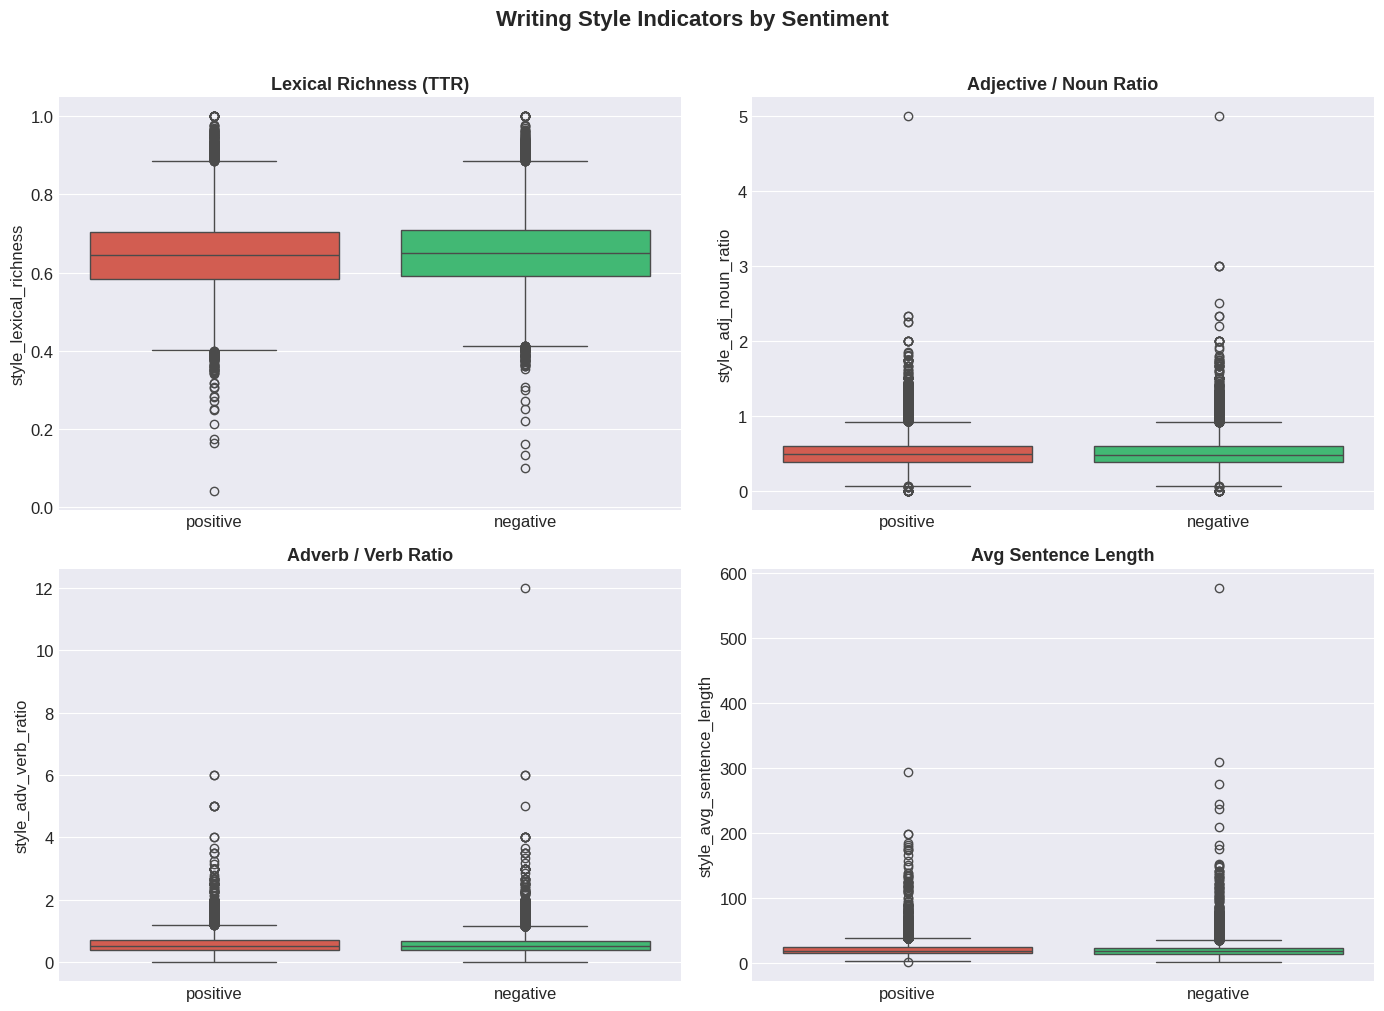


 Average POS Tag Counts by Sentiment:


,style_noun_count,style_verb_count,style_adj_count,style_adv_count
sentiment,,,,
negative,41.46,27.29,19.81,14.83
positive,42.20,26.15,20.40,14.11


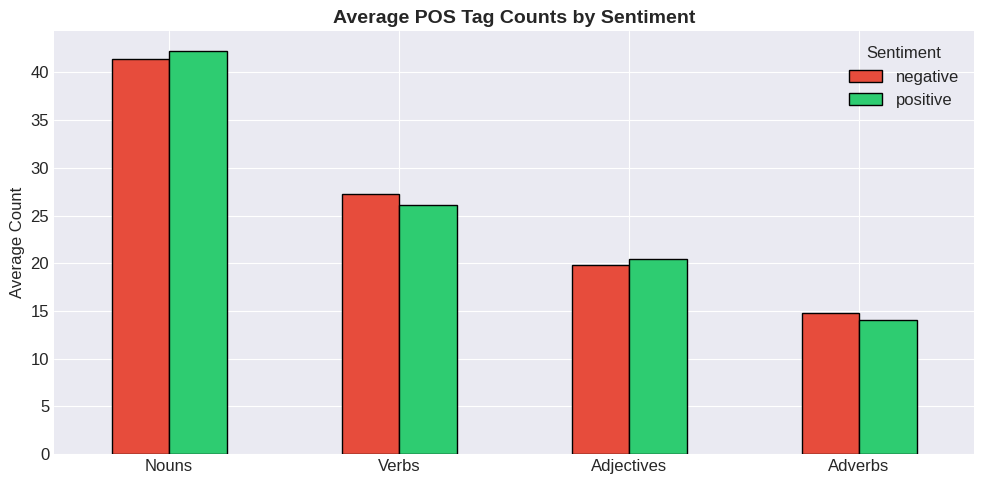


 Section 6 Complete: Writing style indicators extracted using POS tagging.


In [49]:
# Visualize key style metrics by sentiment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('style_lexical_richness', 'Lexical Richness (TTR)'),
    ('style_adj_noun_ratio', 'Adjective / Noun Ratio'),
    ('style_adv_verb_ratio', 'Adverb / Verb Ratio'),
    ('style_avg_sentence_length', 'Avg Sentence Length')
]
for idx, (col, title) in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    sns.boxplot(x='sentiment', y=col, data=df_sample, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Writing Style Indicators by Sentiment', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
# POS Distribution comparison
print("\n Average POS Tag Counts by Sentiment:")
pos_cols = [f'style_{p}' for p in ['noun_count', 'verb_count', 'adj_count', 'adv_count']]
pos_by_sent = df_sample.groupby('sentiment')[pos_cols].mean().round(2)
display(pos_by_sent)
fig, ax = plt.subplots(figsize=(10, 5))
pos_by_sent.T.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Average POS Tag Counts by Sentiment', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Nouns', 'Verbs', 'Adjectives', 'Adverbs'], rotation=0)
ax.set_ylabel('Average Count')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()
print("\n Section 6 Complete: Writing style indicators extracted using POS tagging.")

# ============================================================
# SECTION 7: ASPECT-LEVEL SENTIMENT VALUES
# ============================================================


In [51]:
# Define aspects and their associated keywords
aspect_keywords = {
    'story':     ['story', 'plot', 'script', 'narrative', 'writing', 'screenplay', 'storyline', 'tale'],
    'acting':    ['acting', 'actor', 'actress', 'cast', 'performance', 'performances', 'played', 'role', 'portray'],
    'visuals':   ['visual', 'visuals', 'cinematography', 'effects', 'cgi', 'camera', 'shot', 'shots', 'scenery', 'animation'],
    'music':     ['music', 'score', 'soundtrack', 'song', 'songs', 'theme', 'musical', 'sound', 'audio', 'compose'],
    'direction': ['direction', 'director', 'directed', 'directing', 'pacing', 'pace', 'editing', 'edit']
}
print("\n Aspect Keywords Defined:")
for aspect, kws in aspect_keywords.items():
    print(f"   {aspect:10s}: {', '.join(kws)}")



 Aspect Keywords Defined:
   story     : story, plot, script, narrative, writing, screenplay, storyline, tale
   acting    : acting, actor, actress, cast, performance, performances, played, role, portray
   visuals   : visual, visuals, cinematography, effects, cgi, camera, shot, shots, scenery, animation
   music     : music, score, soundtrack, song, songs, theme, musical, sound, audio, compose
   direction : direction, director, directed, directing, pacing, pace, editing, edit


In [54]:
#  Function to extract aspect-level sentiments
def extract_aspect_sentiments(text):
    """
    For each aspect:
    1. Split review into sentences
    2. Find sentences mentioning aspect keywords
    3. Compute TextBlob polarity for those sentences
    4. Average polarities = aspect sentiment

    Returns dict with aspect → sentiment score (-1 to +1) or None if not mentioned.
    """
    text_lower = text.lower()
    sentences = sent_tokenize(text_lower)

    aspect_sentiments = {}

    for aspect, keywords in aspect_keywords.items():
        matching_polarities = []
        for sentence in sentences:
            if any(kw in sentence for kw in keywords):
                polarity = TextBlob(sentence).sentiment.polarity
                matching_polarities.append(polarity)

        if matching_polarities:
            avg_polarity = sum(matching_polarities) / len(matching_polarities)
            aspect_sentiments[aspect] = round(avg_polarity, 4)
        else:
            aspect_sentiments[aspect] = None  # Aspect not mentioned

    return aspect_sentiments

# Apply aspect sentiment extraction
print("\n Extracting aspect-level sentiments...")
df_sample['aspect_sentiments'] = df_sample['review'].apply(extract_aspect_sentiments)
print(" Aspect sentiments extracted!")


 Extracting aspect-level sentiments...
 Aspect sentiments extracted!


In [55]:
#  Expand into separate columns
aspect_df = pd.DataFrame(df_sample['aspect_sentiments'].tolist())
for col in aspect_df.columns:
    df_sample[f'aspect_{col}'] = aspect_df[col]
#  Display sample
print("\n--- Aspect Sentiments for First 5 Reviews ---")
aspect_cols = [f'aspect_{a}' for a in aspect_keywords.keys()]
display(df_sample[['sentiment'] + aspect_cols].head(10))
# # 7.7 Average aspect sentiment by overall sentiment class
print("\n📊 Average Aspect Sentiment by Sentiment Class:")
aspect_by_sent = df_sample.groupby('sentiment')[aspect_cols].mean().round(4)
display(aspect_by_sent) Aspect mention frequency
print("\n How often is each aspect mentioned?")
aspect_mention_counts = {}
for aspect in aspect_keywords:
    col = f'aspect_{aspect}'
    mentioned = df_sample[col].notna().sum()
    aspect_mention_counts[aspect] = mentioned
    pct = mentioned / len(df_sample) * 100
    print(f"   {aspect:10s}: {mentioned:4d} reviews ({pct:.1f}%)")


--- Aspect Sentiments for First 5 Reviews ---


,sentiment,aspect_story,aspect_acting,aspect_visuals,aspect_music,aspect_direction
0,positive,NaN,NaN,NaN,NaN,NaN
1,positive,NaN,NaN,0.1862,NaN,NaN
2,negative,0.1250,0.3667,NaN,NaN,NaN
3,positive,NaN,NaN,NaN,NaN,NaN
4,negative,-0.0250,NaN,NaN,NaN,NaN
5,positive,0.2333,0.1847,NaN,NaN,0.5317
6,positive,-0.7500,NaN,NaN,-0.0125,NaN
7,positive,0.2500,NaN,NaN,-0.1250,NaN
8,negative,NaN,NaN,NaN,0.0000,-0.1483
9,negative,0.2472,-0.0872,0.1163,NaN,0.0857



📊 How often is each aspect mentioned?
   story     : 29859 reviews (59.7%)
   acting    : 30229 reviews (60.5%)
   visuals   : 13662 reviews (27.3%)
   music     : 13219 reviews (26.4%)
   direction : 16755 reviews (33.5%)


In [56]:
#  Average aspect sentiment by overall sentiment class
print("\n Average Aspect Sentiment by Sentiment Class:")
aspect_by_sent = df_sample.groupby('sentiment')[aspect_cols].mean().round(4)
display(aspect_by_sent)


 Average Aspect Sentiment by Sentiment Class:


,aspect_story,aspect_acting,aspect_visuals,aspect_music,aspect_direction
sentiment,,,,,
negative,-0.0058,0.0146,0.0329,0.0414,0.0089
positive,0.1965,0.2490,0.2234,0.2313,0.2038


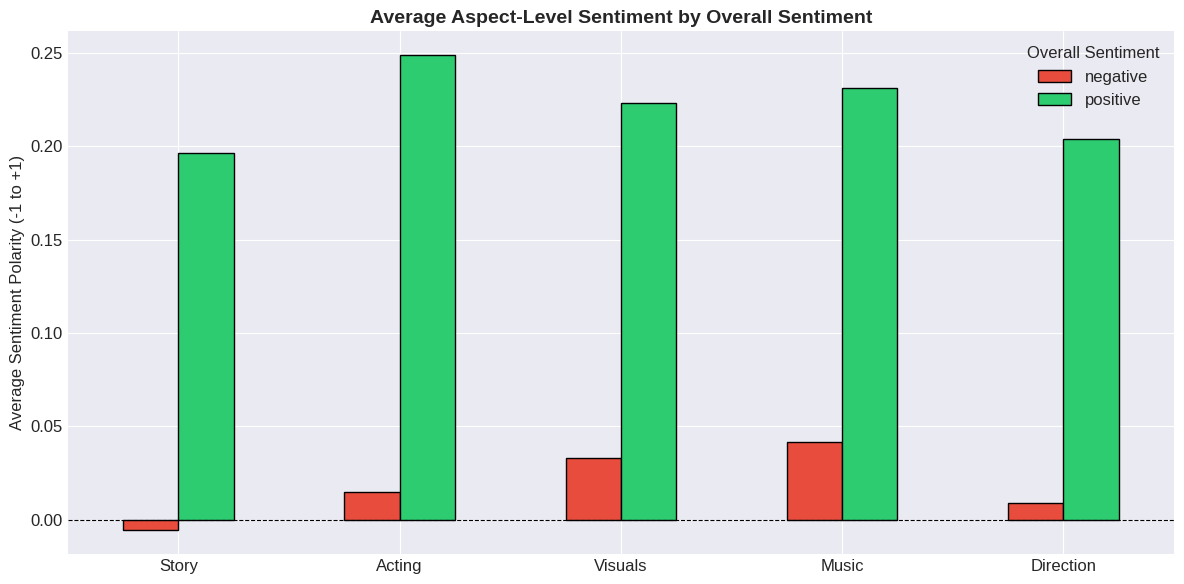

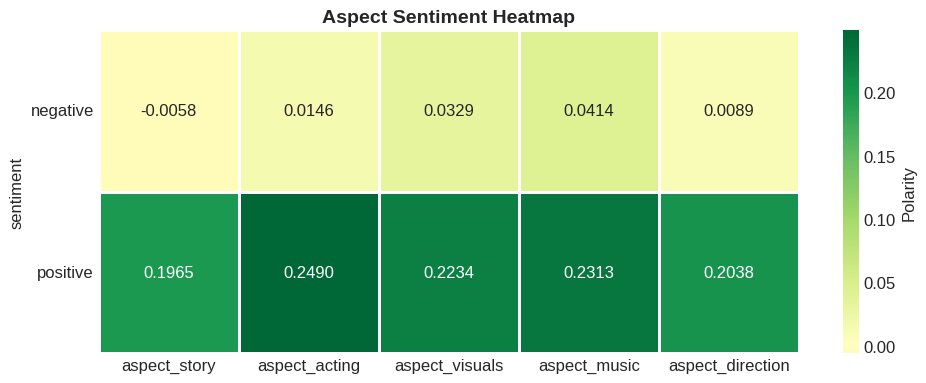


 Section 7 Complete: Aspect-level sentiment values derived for story, acting, visuals, music, direction.


In [57]:
#  Visualization — Aspect sentiment comparison
fig, ax = plt.subplots(figsize=(12, 6))
aspect_by_sent.T.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Average Aspect-Level Sentiment by Overall Sentiment', fontsize=14, fontweight='bold')
ax.set_xticklabels([a.replace('aspect_', '').title() for a in aspect_cols], rotation=0)
ax.set_ylabel('Average Sentiment Polarity (-1 to +1)')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.legend(title='Overall Sentiment')
plt.tight_layout()
plt.show()
#  Heatmap of aspect sentiments
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(aspect_by_sent, annot=True, cmap='RdYlGn', center=0, fmt='.4f',
            linewidths=1, ax=ax, cbar_kws={'label': 'Polarity'})
ax.set_title('Aspect Sentiment Heatmap', fontsize=14, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()
print("\n Section 7 Complete: Aspect-level sentiment values derived for story, acting, visuals, music, direction.")

# ============================================================
# SECTION 8: CONTEXTUAL EMBEDDINGS USING BERT
# ============================================================

In [58]:
#  Load pretrained BERT-based sentence transformer
print("\n Loading pretrained BERT model (all-MiniLM-L6-v2)...")
print("   This is a lightweight BERT model (~80 MB) optimized for sentence embeddings.")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print(" BERT model loaded!")


 Loading pretrained BERT model (all-MiniLM-L6-v2)...
   This is a lightweight BERT model (~80 MB) optimized for sentence embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 BERT model loaded!


In [65]:
# Generate BERT embeddings for all reviews
print("\n Generating contextual BERT embeddings for all reviews...")
bert_embeddings = bert_model.encode(
    df_sample['processed_review'].tolist(),
    show_progress_bar=True,
    batch_size=32
)
print(f"✅ Embeddings generated! Shape: {bert_embeddings.shape}")
print(f"   → Each review is represented as a {bert_embeddings.shape[1]}-dimensional vector")

# Store embeddings
df_sample['bert_embedding'] = list(bert_embeddings)


 Generating contextual BERT embeddings for all reviews...


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

✅ Embeddings generated! Shape: (50000, 384)
   → Each review is represented as a 384-dimensional vector



 Computing cosine similarity matrix for first 10 reviews...


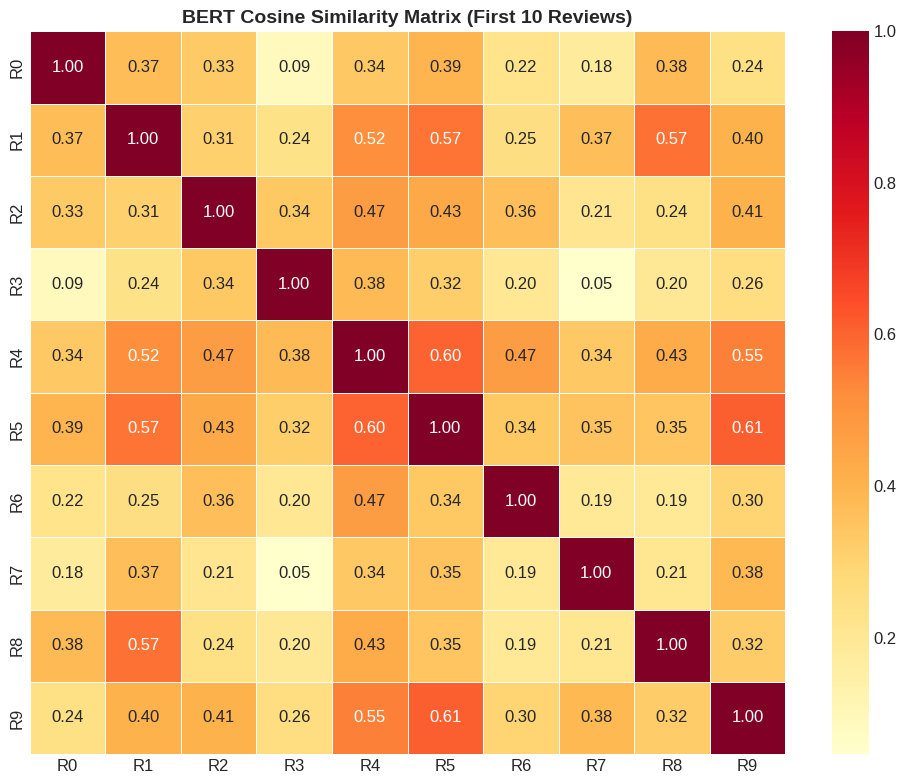

In [66]:
#  Compute pairwise similarity matrix (for top N reviews)
TOP_N = 10  # For visualization
print(f"\n Computing cosine similarity matrix for first {TOP_N} reviews...")
sim_matrix = cosine_similarity(bert_embeddings[:TOP_N])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'R{i}' for i in range(TOP_N)],
            yticklabels=[f'R{i}' for i in range(TOP_N)],
            ax=ax, linewidths=0.5)
ax.set_title(f'BERT Cosine Similarity Matrix (First {TOP_N} Reviews)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [67]:
# Find most similar reviews — Demo
print("\n" + "=" * 50)
print(" CONTEXTUAL SIMILARITY DEMO")
print("=" * 50)
target_idx = 0
target_embedding = bert_embeddings[target_idx].reshape(1, -1)
all_similarities = cosine_similarity(target_embedding, bert_embeddings)[0]
# Get top 3 most similar (excluding self)
similar_indices = all_similarities.argsort()[-4:-1][::-1]
print(f"\n Target Review (Index {target_idx}):")
print(f"   Sentiment: {df_sample['sentiment'].iloc[target_idx]}")
print(f"   Text: {df_sample['review'].iloc[target_idx][:200]}...\n")
for rank, idx in enumerate(similar_indices, 1):
    score = all_similarities[idx]
    print(f"     Similar #{rank} (Score: {score:.4f}) — Sentiment: {df_sample['sentiment'].iloc[idx]}")
    print(f"      {df_sample['review'].iloc[idx][:150]}...\n")


 CONTEXTUAL SIMILARITY DEMO

 Target Review (Index 0):
   Sentiment: positive
   Text: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...

     Similar #1 (Score: 0.7973) — Sentiment: negative
      no way out 2007 was a really bad and if it is the road to wrestlemania they choose the wrong road.<br /><br />Chris Benoit & the hardy boys def MVP & ...

     Similar #2 (Score: 0.7745) — Sentiment: positive
      *SPOILERS*<br /><br />This is only the second pay-per-view I've given a perfect 10, the first being the 1991 Royal Rumble. It was full of exciting mat...

     Similar #3 (Score: 0.7722) — Sentiment: negative
      The worst Wrestlemania ever.<br /><br />This had no must see bouts and many crap ones at that. This took place in Las Vegas and WWE made it's employee...



 Visualizing BERT embeddings using PCA (2D projection)...


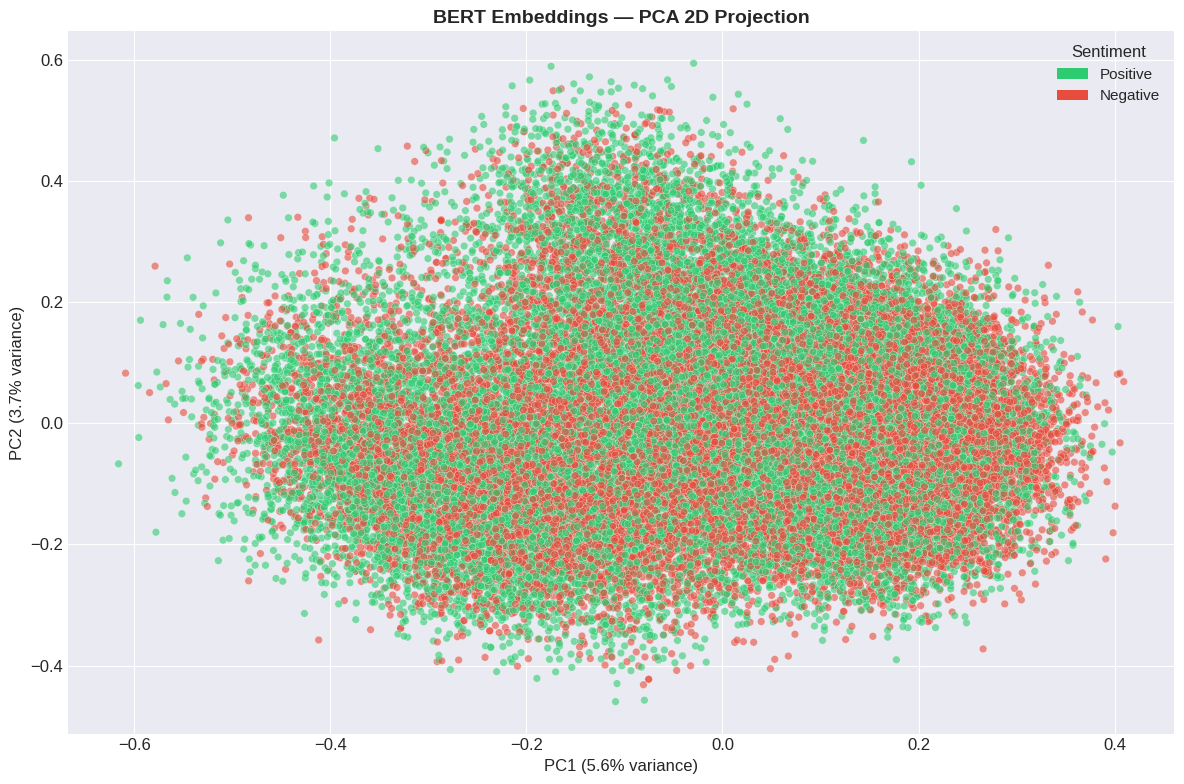


 Section 8 Complete: Contextual BERT embeddings generated and similarity analysis performed.


In [68]:
#  Visualize embedding clusters using PCA
from sklearn.decomposition import PCA
print(" Visualizing BERT embeddings using PCA (2D projection)...")
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(bert_embeddings)
fig, ax = plt.subplots(figsize=(12, 8))
colors = df_sample['sentiment_label'].map({1: '#2ecc71', 0: '#e74c3c'})
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                     c=colors, alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
ax.set_title('BERT Embeddings — PCA 2D Projection', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Positive'),
                   Patch(facecolor='#e74c3c', label='Negative')]
ax.legend(handles=legend_elements, title='Sentiment', fontsize=11)
plt.tight_layout()
plt.show()
print("\n Section 8 Complete: Contextual BERT embeddings generated and similarity analysis performed.")

# ============================================================
# SECTION 9: CONSOLIDATED CINEMATIC INTELLIGENCE PROFILE
# ============================================================

In [69]:
#  Build the consolidated profile for each review
def build_cinematic_profile(row):
    """
    Consolidate all NLP outputs into a single 'Cinematic Intelligence Profile'
    for each review.
    """
    profile = {
        # --- Overall Sentiment ---
        'overall_sentiment': row['sentiment'],
        'tfidf_prediction': row.get('tfidf_predicted_label', 'N/A'),

        # --- Emotion Profile ---
        'emotion_profile': row.get('emotion_scores', {}),
        'dominant_emotion': row.get('dominant_emotion', 'N/A'),

        # --- Writing Style ---
        'writing_style': {
            'lexical_richness': row.get('style_lexical_richness', 0),
            'adj_noun_ratio': row.get('style_adj_noun_ratio', 0),
            'adv_verb_ratio': row.get('style_adv_verb_ratio', 0),
            'avg_sentence_length': row.get('style_avg_sentence_length', 0),
            'sentence_count': row.get('style_sentence_count', 0),
        },

        # --- Aspect Sentiments ---
        'aspect_sentiments': row.get('aspect_sentiments', {}),

        # --- Contextual Embedding (first 5 dims as preview) ---
        'bert_embedding_preview': list(row['bert_embedding'][:5]) if 'bert_embedding' in row.index else []
    }
    return profile
print("\n Building unified Cinematic Intelligence Profiles...")
df_sample['cinematic_profile'] = df_sample.apply(build_cinematic_profile, axis=1)
print(" Profiles created for all reviews!")



 Building unified Cinematic Intelligence Profiles...
 Profiles created for all reviews!


In [70]:
# Display full profile for sample reviews
print("\n" + "=" * 70)
print("  CINEMATIC INTELLIGENCE PROFILES — SAMPLE REVIEWS")
print("=" * 70)
for i in range(5):
    profile = df_sample['cinematic_profile'].iloc[i]
    review_text = df_sample['review'].iloc[i][:200]

    print(f"\n{'─'*70}")
    print(f" REVIEW #{i+1}")
    print(f"{'─'*70}")
    print(f"Text: {review_text}...")
    print(f"\n    Overall Sentiment:    {profile['overall_sentiment']}")
    print(f"    TF-IDF Prediction:   {profile['tfidf_prediction']}")
    print(f"    Dominant Emotion:     {profile['dominant_emotion']}")

    print(f"\n    Emotion Scores:")
    for emo, score in profile['emotion_profile'].items():
        bar = '█' * int(score * 50) if score else ''
        print(f"      {emo:10s}: {score:.4f} {bar}")

    print(f"\n     Writing Style:")
    ws = profile['writing_style']
    print(f"      Lexical Richness:     {ws['lexical_richness']:.4f}")
    print(f"      Adj/Noun Ratio:       {ws['adj_noun_ratio']:.4f}")
    print(f"      Adv/Verb Ratio:       {ws['adv_verb_ratio']:.4f}")
    print(f"      Avg Sentence Length:  {ws['avg_sentence_length']:.2f}")
    print(f"      Sentence Count:       {ws['sentence_count']}")

    print(f"\n    Aspect Sentiments:")
    for aspect, score in profile['aspect_sentiments'].items():
        if score is not None:
            sentiment_label = "Positive " if score > 0 else "Negative " if score < 0 else "Neutral "
            print(f"      {aspect:10s}: {score:+.4f} ({sentiment_label})")
        else:
            print(f"      {aspect:10s}: Not mentioned")

    print(f"\n    BERT Embedding (first 5 dims): {[round(x, 4) for x in profile['bert_embedding_preview']]}")


  CINEMATIC INTELLIGENCE PROFILES — SAMPLE REVIEWS

──────────────────────────────────────────────────────────────────────
 REVIEW #1
──────────────────────────────────────────────────────────────────────
Text: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...

    Overall Sentiment:    positive
    TF-IDF Prediction:   negative
    Dominant Emotion:     anger

    Emotion Scores:
      joy       : 0.6943 ██████████████████████████████████
      anger     : 0.7452 █████████████████████████████████████
      sadness   : 0.6749 █████████████████████████████████
      surprise  : 0.6217 ███████████████████████████████
      disgust   : 0.7335 ████████████████████████████████████

     Writing Style:
      Lexical Richness:     0.6080
      Adj/Noun Ratio:       0.7200
      Adv/Verb Ratio:       0.9231
      Avg Sentence Length:  33.17


In [72]:
# Save final output to CSV
print(f"\n{'='*70}")
print(" SAVING RESULTS")
print(f"{'='*70}")
# Prepare export dataframe (drop heavy embedding column)
export_cols = ['review', 'sentiment', 'sentiment_label', 'cleaned_review', 'processed_review',
               'tfidf_predicted_label', 'dominant_emotion']
export_cols += [f'emotion_{e}' for e in emotion_lexicon.keys()]
export_cols += [f'style_{c}' for c in ['lexical_richness', 'adj_noun_ratio', 'adv_verb_ratio',
                                        'sentence_count', 'avg_sentence_length']]
export_cols += [f'aspect_{a}' for a in aspect_keywords.keys()]
# Filter only existing columns
export_cols = [c for c in export_cols if c in df_sample.columns]
df_export = df_sample[export_cols]
output_path = "cinematic_intelligence_profiles.csv"
df_export.to_csv(output_path, index=False)
print(f"\n Results saved to: {output_path}")
print(f"   Total reviews processed: {len(df_export)}")
print(f"   Total features per review: {len(export_cols)}")


 SAVING RESULTS

 Results saved to: cinematic_intelligence_profiles.csv
   Total reviews processed: 50000
   Total features per review: 22


In [74]:
#  Final Summary
print(f"\n{'='*70}")
print(" CINEMATIC INTELLIGENCE PROJECT — EXECUTION SUMMARY")
print(f"{'='*70}")

print(" Project Complete! All outputs consolidated into cinematic_intelligence_profiles.csv")


 CINEMATIC INTELLIGENCE PROJECT — EXECUTION SUMMARY
 Project Complete! All outputs consolidated into cinematic_intelligence_profiles.csv


**Submitted By - Kuldeep panwar**
